Loaded file from: HR_comma_sep.csv

Columns found: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

First 5 rows:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident         

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


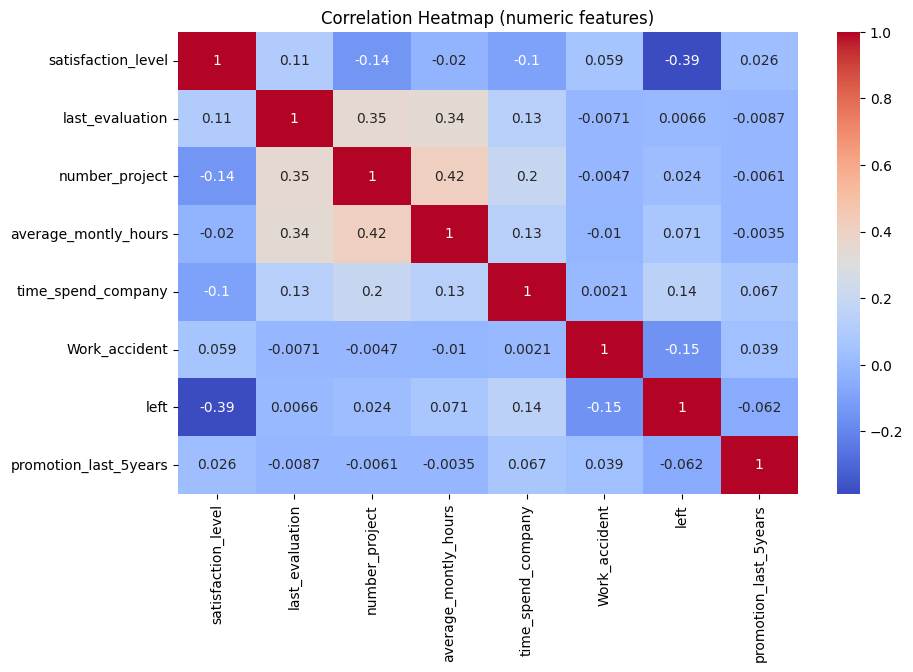


Correlation of numeric features with 'left':
left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


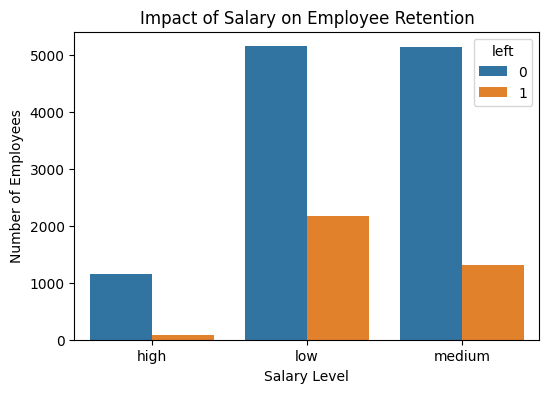

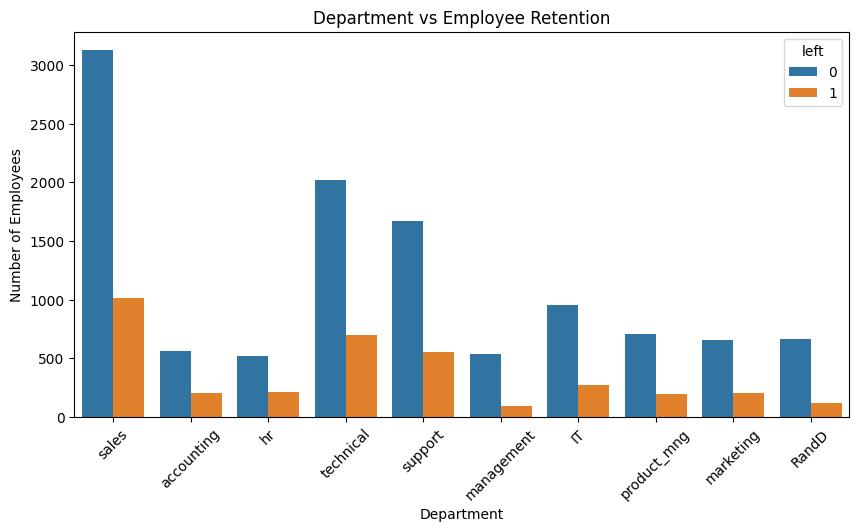


Feature columns used for modeling: ['satisfaction_level', 'average_montly_hours', 'promotion_last_5years', 'salary_low', 'salary_medium']

===== Model Evaluation =====
Accuracy: 0.7816666666666666

Confusion Matrix:
 [[2151  135]
 [ 520  194]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.94      0.87      2286
           1       0.59      0.27      0.37       714

    accuracy                           0.78      3000
   macro avg       0.70      0.61      0.62      3000
weighted avg       0.75      0.78      0.75      3000


Feature coefficients (sorted by absolute importance):


,0
satisfaction_level,-3.725577
salary_low,1.609764
salary_medium,1.126897
promotion_last_5years,-0.980802
average_montly_hours,0.002269



Example prediction demonstration:
Example input (matching columns):


,satisfaction_level,average_montly_hours,promotion_last_5years,salary_low,salary_medium
0,0.8,150,0,0,0


Predicted label: 0  (1 = will leave, 0 = will stay)
Predicted probabilities: stay=0.970, leave=0.030

All done. If you want, you can modify 'example_values' above to test different cases.


In [2]:
# ===== Logistic Regression: Employee Retention Analysis (HR Analytics) =====
# This cell auto-loads HR_comma_sep.csv (from current session, Drive, or manual upload),
# performs EDA, builds a logistic regression model, evaluates it, and shows an example prediction.

# ------------------ Imports ------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# For manual upload fallback in Colab
try:
    from google.colab import files, drive
    COLAB = True
except Exception:
    COLAB = False

# ------------------ Load dataset (robust) ------------------
def load_hr_csv(filename="HR_comma_sep.csv"):
    # 1) Try local working directory
    if os.path.exists(filename):
        return pd.read_csv(filename), filename

    # 2) Common Colab location (/content)
    alt = os.path.join("/content", filename)
    if os.path.exists(alt):
        return pd.read_csv(alt), alt

    # 3) Try Google Drive (if running in Colab)
    if COLAB:
        try:
            drive.mount('/content/drive', force_remount=False)
        except Exception:
            pass
        possible_paths = [
            os.path.join("/content/drive/MyDrive", filename),
            os.path.join("/content/drive/MyDrive/Colab Notebooks", filename),
            os.path.join("/content/drive/Shareddrives", filename),
            os.path.join("/content/drive/MyDrive/datasets", filename)
        ]
        for p in possible_paths:
            if os.path.exists(p):
                return pd.read_csv(p), p

    # 4) Ask user to upload manually (works in Colab)
    if COLAB:
        print("File not found automatically. Please upload the CSV file now (choose HR_comma_sep.csv):")
        uploaded = files.upload()
        # uploaded is dict {filename: bytes}
        if filename in uploaded:
            # save to /content for consistent path
            with open(filename, "wb") as f:
                f.write(uploaded[filename])
            return pd.read_csv(filename), filename
        else:
            # if user uploaded with different name, take the first file
            first = next(iter(uploaded.keys()))
            with open(first, "wb") as f:
                f.write(uploaded[first])
            return pd.read_csv(first), first

    # 5) If all fails, raise error
    raise FileNotFoundError(f"Could not find {filename}. Place it in the notebook folder or upload it.")

# Load
hr, loaded_path = load_hr_csv()
print(f"Loaded file from: {loaded_path}")
print("\nColumns found:", list(hr.columns))
print("\nFirst 5 rows:")
display(hr.head())

# ------------------ Basic info ------------------
print("\nDataset info:")
print(hr.info())
print("\nMissing values per column:")
print(hr.isnull().sum())

print("\nBasic statistics:")
display(hr.describe(include='all'))

# ------------------ Normalize column names (be tolerant) ------------------
# Some versions of the dataset use 'Department' or 'department'. We'll standardize a bit.
cols = {c: c.strip() for c in hr.columns}
hr.rename(columns=cols, inplace=True)

# make column name for department consistent
if 'Department' in hr.columns and 'department' not in hr.columns:
    hr.rename(columns={'Department': 'department'}, inplace=True)
if 'salary' not in hr.columns and 'Salary' in hr.columns:
    hr.rename(columns={'Salary': 'salary'}, inplace=True)

# ------------------ Correlation heatmap ------------------
plt.figure(figsize=(10,6))
sns.heatmap(hr.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (numeric features)')
plt.show()

# Quick sorted correlation with target 'left' (if present)
if 'left' in hr.columns:
    print("\nCorrelation of numeric features with 'left':")
    print(hr.corr(numeric_only=True)['left'].sort_values(ascending=False))

# ------------------ Bar charts: salary vs left and department vs left ------------------
if 'salary' in hr.columns and 'left' in hr.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='salary', hue='left', data=hr, order=sorted(hr['salary'].unique()))
    plt.title('Impact of Salary on Employee Retention')
    plt.xlabel('Salary Level')
    plt.ylabel('Number of Employees')
    plt.show()
else:
    print("Column 'salary' or 'left' missing; skipping salary plot.")

if 'department' in hr.columns and 'left' in hr.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(x='department', hue='left', data=hr)
    plt.title('Department vs Employee Retention')
    plt.xlabel('Department')
    plt.ylabel('Number of Employees')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Column 'department' or 'left' missing; skipping department plot.")

# ------------------ Prepare features for logistic regression ------------------
# We'll pick the most impactful features commonly used: satisfaction_level, average_montly_hours, promotion_last_5years, salary (as dummies)
required_features = ['satisfaction_level', 'average_montly_hours', 'promotion_last_5years', 'salary', 'left']
missing = [f for f in required_features if f not in hr.columns]
if missing:
    print(f"Warning: expected columns missing from dataset: {missing}")
    # We'll still try to proceed with whatever numeric columns + salary if available

# Build feature DataFrame
features = []
if 'satisfaction_level' in hr.columns:
    features.append('satisfaction_level')
if 'average_montly_hours' in hr.columns:
    features.append('average_montly_hours')
if 'promotion_last_5years' in hr.columns:
    features.append('promotion_last_5years')

X = hr[features].copy()

# handle salary dummies if present
if 'salary' in hr.columns:
    salary_dummies = pd.get_dummies(hr['salary'], prefix='salary', drop_first=True)
    X = pd.concat([X, salary_dummies], axis=1)

# target
if 'left' not in hr.columns:
    raise KeyError("Target column 'left' not found in dataset.")
y = hr['left']

print("\nFeature columns used for modeling:", list(X.columns))

# ------------------ Train-test split ------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# ------------------ Train Logistic Regression ------------------
# Use solver and more iterations to avoid warnings
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

# ------------------ Evaluate ------------------
y_pred = model.predict(X_test)
print("\n===== Model Evaluation =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------ Feature coefficients ------------------
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("\nFeature coefficients (sorted by absolute importance):")
display(coefs)

# ------------------ Example / Demo prediction ------------------
# Build an example dict matching the X columns. We'll show how to create it generically.
print("\nExample prediction demonstration:")
# Example values (you can change these)
example_values = {
    'satisfaction_level': 0.80,
    'average_montly_hours': 150,
    'promotion_last_5years': 0
}
# For salary dummies, set the same columns as in X (all zeros means 'low' if drop_first used)
for col in X.columns:
    if col.startswith('salary_') and col not in example_values:
        example_values[col] = 0

# Ensure all columns present and ordered like X
example_df = pd.DataFrame([ [example_values.get(c, 0) for c in X.columns] ], columns=X.columns)
print("Example input (matching columns):")
display(example_df)

pred = model.predict(example_df)[0]
pred_proba = model.predict_proba(example_df)[0]
print(f"Predicted label: {pred}  (1 = will leave, 0 = will stay)")
print(f"Predicted probabilities: stay={pred_proba[0]:.3f}, leave={pred_proba[1]:.3f}")

# ------------------ Done ------------------
print("\nAll done. If you want, you can modify 'example_values' above to test different cases.")
